In [39]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
import nltk

FILE_PATH = "/content/youtube_phase2_cleaned.csv"

df = pd.read_csv(FILE_PATH)


print("\nColumns in the dataset:")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

print("\nDataset Shape:")
print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")

print("\nFirst 3 Rows of the Dataset:")
display(df.head(3))


Columns in the dataset:
1. kind
2. commentId
3. videoId
4. publishedAt
5. updatedAt
6. textDisplay
7. likeCount
8. text_clean
9. publishedAt_dt
10. updatedAt_dt
11. text_processed

Dataset Shape:
Rows: 3781 | Columns: 11

First 3 Rows of the Dataset:


,kind,commentId,videoId,publishedAt,updatedAt,textDisplay,likeCount,text_clean,publishedAt_dt,updatedAt_dt,text_processed
0,youtube#comment,Ugz3TjxB2c5U0i01kht4AaABAg,Z2UqlSo3G-A,2026-02-11T18:29:35Z,2026-02-11T18:29:35Z,Crazy.,0,Crazy.,2026-02-11 18:29:35+00:00,2026-02-11 18:29:35+00:00,crazy
1,youtube#comment,Ugz3M8msHzpXu3-VZsJ4AaABAg,Z2UqlSo3G-A,2026-02-11T18:27:52Z,2026-02-11T18:27:52Z,They aren't going to let us have this vaccine....,0,They aren't going to let us have this vaccine....,2026-02-11 18:27:52+00:00,2026-02-11 18:27:52+00:00,be not go let vaccine vaccine ffs mrna vaccine...
2,youtube#comment,UgwQPhsmvJ6RkrehQ1V4AaABAg,Z2UqlSo3G-A,2026-02-11T18:27:09Z,2026-02-11T18:27:09Z,Well...the rich will get vaccinated abroad if ...,0,Well...the rich will get vaccinated abroad if ...,2026-02-11 18:27:09+00:00,2026-02-11 18:27:09+00:00,wellthe rich get vaccinate abroad good


In [ ]:
#  Identify columns

TEXT_COL = "text_clean"
DATE_COL = "publishedAt_dt"


if TEXT_COL not in df.columns:
    for c in df.columns:
        if "text" in c.lower() or "comment" in c.lower():
            TEXT_COL = c
            break

if DATE_COL not in df.columns:
    for c in df.columns:
        if "published" in c.lower() or "date" in c.lower() or "time" in c.lower():
            DATE_COL = c
            break

print("\n Using TEXT_COL =", TEXT_COL)
print(" Using DATE_COL =", DATE_COL)



 Using TEXT_COL = text_clean
 Using DATE_COL = publishedAt_dt


In [ ]:

num_comments = len(df)
print(" Number of comments:", num_comments)

 Number of comments: 3781


/tmp/ipykernel_1143/1570817781.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.dropna(subset=[DATE_COL]).set_index(DATE_COL).resample("M").size()


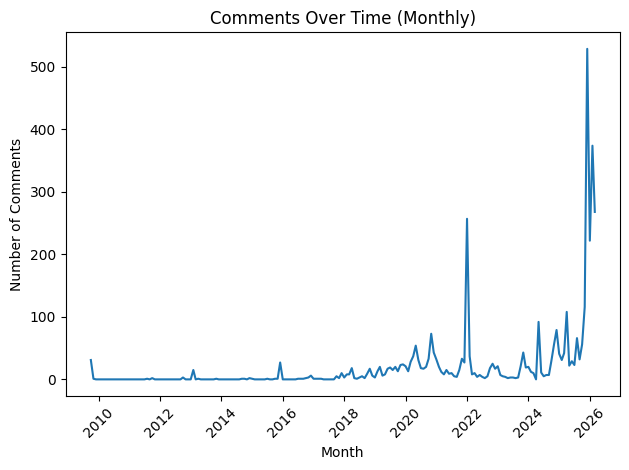

In [ ]:
# Time distribution
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")

monthly = df.dropna(subset=[DATE_COL]).set_index(DATE_COL).resample("M").size()

plt.figure()
plt.plot(monthly.index, monthly.values)
plt.title("Comments Over Time (Monthly)")
plt.xlabel("Month")
plt.ylabel("Number of Comments")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

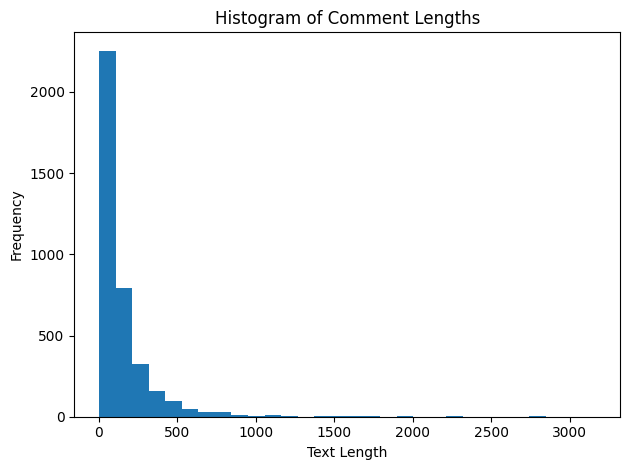

 Text Length Summary:
count    3781.000000
mean      146.909548
std       206.564924
min         3.000000
25%        40.000000
50%        84.000000
75%       173.000000
max      3162.000000
Name: text_length, dtype: float64


In [ ]:
#  Text Length analysis
df["text_length"] = df[TEXT_COL].astype(str).apply(len)

plt.figure()
plt.hist(df["text_length"], bins=30)
plt.title("Histogram of Comment Lengths")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print(" Text Length Summary:")
print(df["text_length"].describe())

 Top 15 Most Common Words:
flu         2306
shot        1332
got          670
vaccine      617
sick         445
covid        413
just         394
year         391
vaccines     385
people       385
don          377
years        364
shots        351
like         331
getting      312
dtype: int64


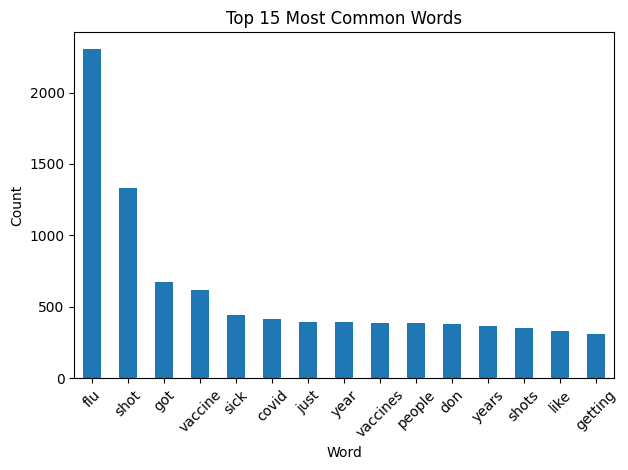

In [ ]:
#unigram
vectorizer = CountVectorizer(stop_words="english", max_features=15)
X = vectorizer.fit_transform(df[TEXT_COL].fillna("").astype(str))

word_counts = pd.Series(
    X.sum(axis=0).A1,
    index=vectorizer.get_feature_names_out()
).sort_values(ascending=False)

print(" Top 15 Most Common Words:")
print(word_counts)

plt.figure()
word_counts.plot(kind="bar")
plt.title("Top 15 Most Common Words")
plt.xlabel("Word")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Top 15 Most Common Bigrams:
flu shot         933
got flu          270
flu shots        172
flu vaccine      169
getting flu      112
years ago         71
shot year         67
big pharma        62
got sick          62
flu jab           53
shot got          52
gotten flu        43
took flu          42
covid vaccine     40
just got          38
dtype: int64


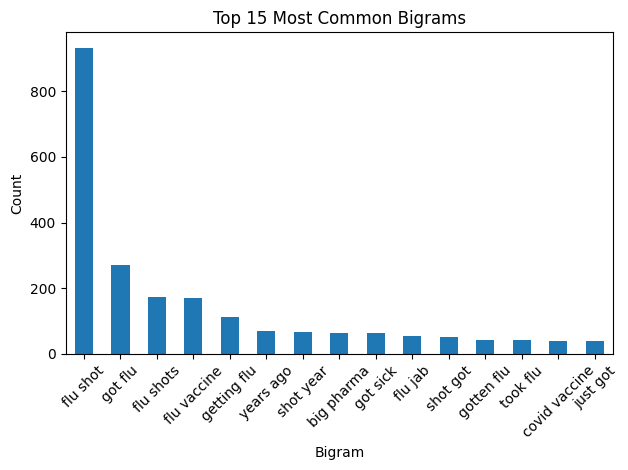

In [ ]:
#bigram

vectorizer_bigram = CountVectorizer(
    stop_words="english",
    ngram_range=(2,2),
    max_features=15
)

X_bigram = vectorizer_bigram.fit_transform(df[TEXT_COL].fillna("").astype(str))

bigram_counts = pd.Series(
    X_bigram.sum(axis=0).A1,
    index=vectorizer_bigram.get_feature_names_out()
).sort_values(ascending=False)

print("Top 15 Most Common Bigrams:")
print(bigram_counts)

plt.figure()
bigram_counts.plot(kind="bar")
plt.title("Top 15 Most Common Bigrams")
plt.xlabel("Bigram")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


 Sentiment Distribution (VADER):
sentiment
Negative    1764
Positive    1202
Neutral      815
Name: count, dtype: int64


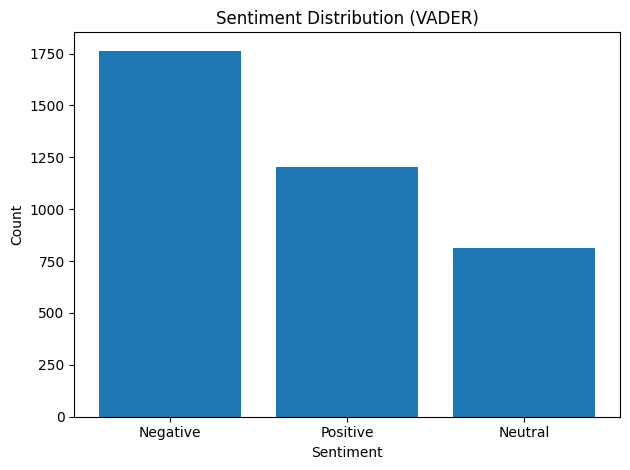

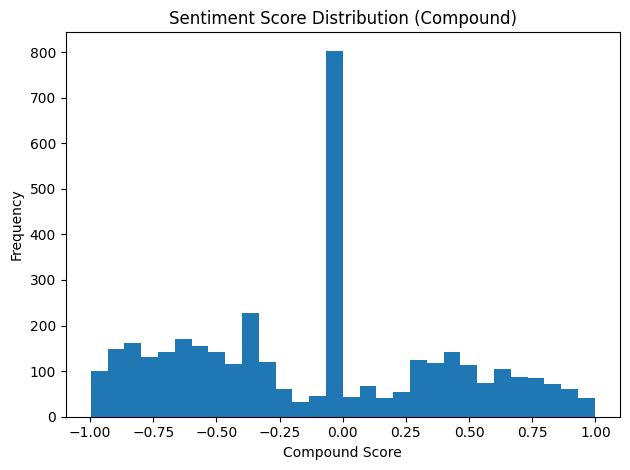

In [ ]:
# Preliminary sentiment

!pip -q install nltk

nltk.download('vader_lexicon')
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

df["sentiment_score"] = df[TEXT_COL].astype(str).apply(
    lambda x: sia.polarity_scores(x)["compound"]
)

def classify_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df["sentiment"] = df["sentiment_score"].apply(classify_sentiment)

sent_counts = df["sentiment"].value_counts()
print(" Sentiment Distribution (VADER):")
print(sent_counts)

# Bar Chart
plt.figure()
plt.bar(sent_counts.index, sent_counts.values)
plt.title("Sentiment Distribution (VADER)")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Histogram of sentiment scores
plt.figure()
plt.hist(df["sentiment_score"], bins=30)
plt.title("Sentiment Score Distribution (Compound)")
plt.xlabel("Compound Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()